Autor: Carlos González Carballo

La **Practica 3: Transfer Learning** consiste en escoger un dataset de HuggingFace y aplicar transfer learning para clasificar imágenes.


El dataset seleccionado es [Human Action Recognition](https://huggingface.co/datasets/Bingsu/Human_Action_Recognition/viewer/default/test?p=2&views%5B%5D=test).

La práctica comenzará con la importación de las librerías y el dataset. Continuará con el estudio del dataset y aplicación de técnicas de limpieza del dataset y balanceo del mismo. Luego, se aplicará transfer learning con diferentes configuraciones y se evaluará el rendimiento del modelo, con el objetivo de obtener un rendimiento óptimo.

# Importación de librerías

In [ ]:
# token = ""
# repo = "carlosgcg00/Practica_3_VC"
# !git clone https://{token}@github.com/{repo}.git

Cloning into 'Practica_3_VC'...
remote: Enumerating objects: 12506, done.
remote: Total 12506 (delta 0), reused 0 (delta 0), pack-reused 12506 (from 1)
Receiving objects: 100% (12506/12506), 120.14 MiB | 12.98 MiB/s, done.
Updating files: 100% (12618/12618), done.


In [ ]:
%cd Practica_3_VC

/content/Practica_3_VC


In [ ]:
from pathlib import Path
import os

env_path = Path(".env")

# Contenido del .env (termina en salto de línea, buena práctica)
# content = "HF_TOKEN=\n"

# Escribir/reescribir .env
env_path.write_text(content, encoding="utf-8")

# Intentar restringir permisos (en Linux/WSL/Colab funciona; en Windows puede ignorarse)
try:
    os.chmod(env_path, 0o600)  # rw------- (solo tu usuario)
except Exception:
    pass

print(f"Creado {env_path.resolve()}")

Creado /content/Practica_3_VC/.env


In [4]:
from datasets import load_dataset, DatasetDict
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from PIL import Image
import os
from dotenv import load_dotenv
import seaborn as sns
from collections import Counter
import math
from utils.utils import *
load_dotenv()

True

Definición de rutas

In [ ]:
FOLDER = "./data"
TRAIN_DIR = os.path.join(FOLDER, "train")
TEST_DIR = os.path.join(FOLDER, "test")
FIGURES_DIR = './figures'

os.makedirs(FOLDER, exist_ok=True)
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

Variables globales

In [ ]:
DPI = 300
DPI_SHOW = 100

# Descarga de los datos

Dataset utilizado: [Human Action Recognition](https://huggingface.co/datasets/Bingsu/Human_Action_Recognition/viewer/default/test?p=2&views%5B%5D=test)

A continuación se realiza la importación/descarga del dataset.

In [7]:
ds = load_dataset("Bingsu/Human_Action_Recognition")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/229M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/98.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12600 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

# Análisis del dataset

En la siguiente celda se muestra un resumen de las características esenciales del dataset.

In [ ]:
labels = ds['train'].features['labels'].names
print(f'Numero de ejemplos de entrenamiento: {ds['train'].shape[0]}')
print(f'Numero de ejemplos de test: {ds['test'].shape[0]}')
print(f'Numero de clases: {len(labels)}')

Numero de ejemplos de entrenamiento: 12600
Numero de ejemplos de test: 5400
Numero de clases: 15


Un estudio muy improtantes es ver que clases tiene el dataset y ver cuantas posibles etiquetas tiene una imagen.

In [ ]:
ds['train'].features['labels']

ClassLabel(names=['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop'])

In [10]:
set(type(x) for x in ds["train"]["labels"])

{int}

Como se acaba de comprobar, se indica en `feature['labels']` e iterando por las diferentes etiquetas y extrayendo su tipo se observa que todas son números enteros, que se corresponde con la posición de la etiqueta en el array de etiquetas. En caso de que se hubiera obtenido una lista o algo similar indicaría que una imagen puede tener varias etiquetas, pero en este caso, **1 imagen solo tiene 1 etiqueta**.

In [11]:
counter_train_df = analysis_dataset(ds['train'], labels)
counter_test_df = analysis_dataset(ds['test'], labels)

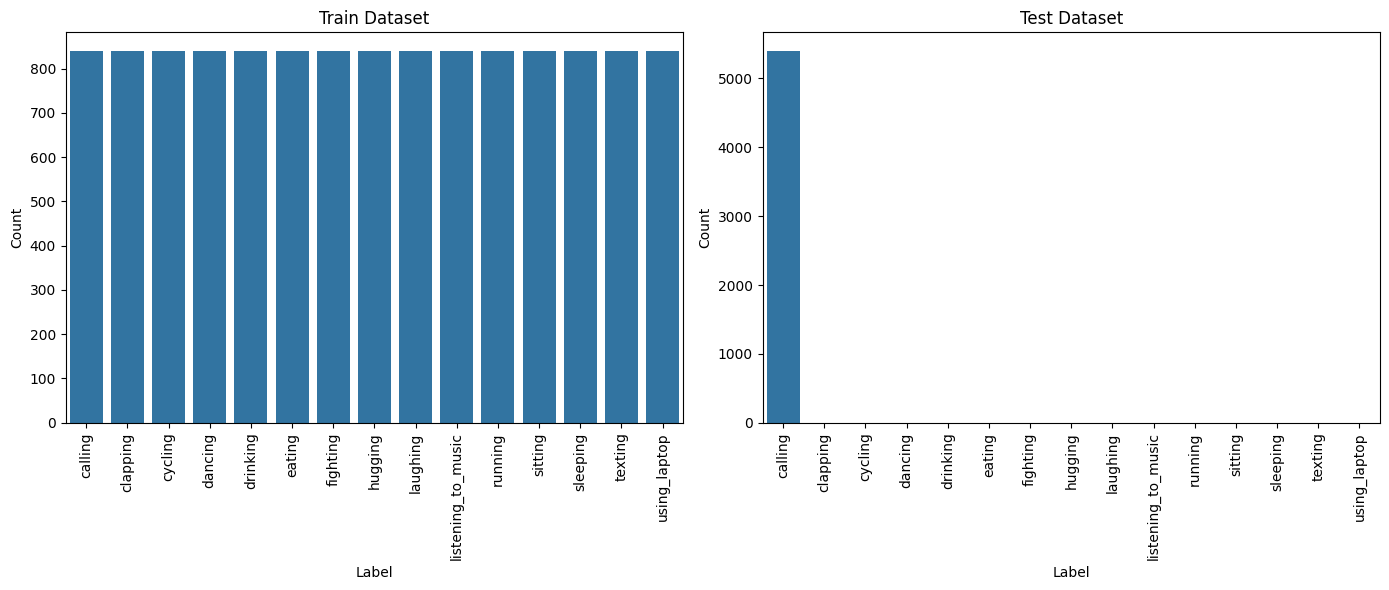

<Figure size 640x480 with 0 Axes>

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), dpi = DPI_SHOW)

sns.barplot(
    data=counter_train_df,
    x="Label",
    y="Count",
    ax=ax[0]
)
ax[0].set_title("Train Dataset")
ax[0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_test_df,
    x="Label",
    y="Count",
    ax=ax[1]
)
ax[1].set_title("Test Dataset")
ax[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()
plt.savefig(f"{FIGURES_DIR}/counter_train_test.png", dpi = DPI)

Los datos de entrenamiento sí están balanceados, mientras que los datos de test no lo están. Antes de tomar una decisión sobre que proceso aplicar para rebalancear y ajustar los datos a continuación se ilustra un set de 4 ejemplos de entrenamiento y 4 de test.

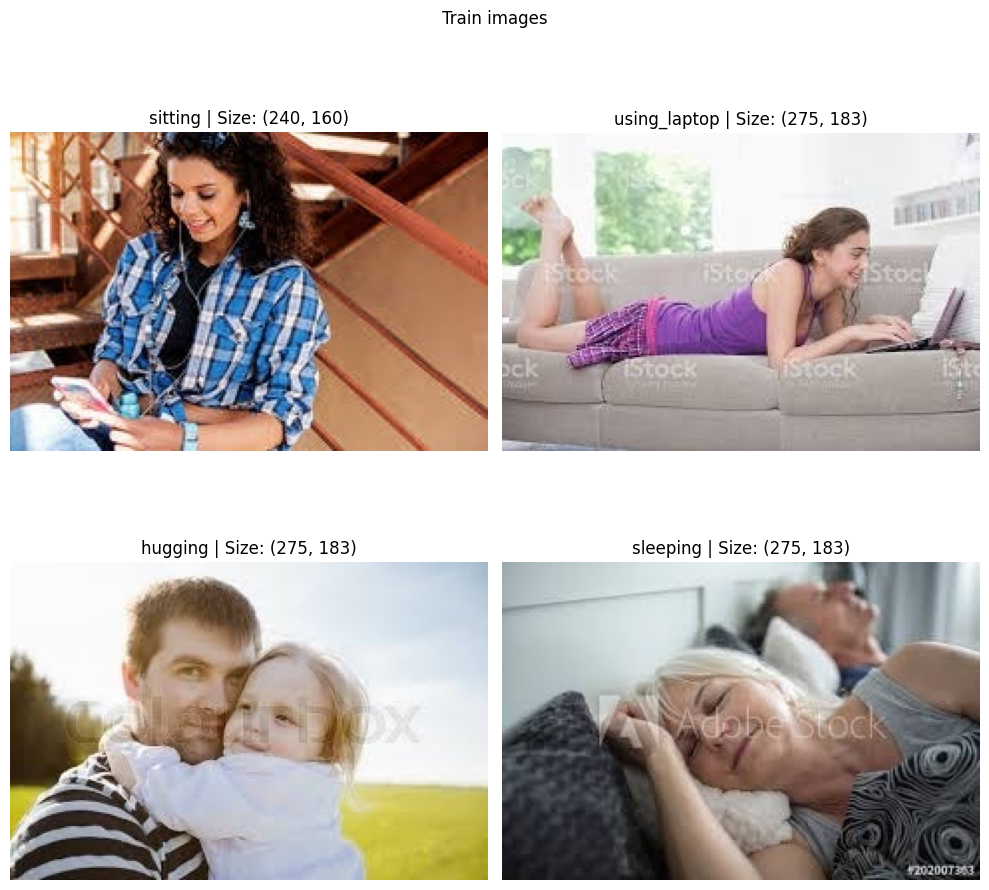

<Figure size 640x480 with 0 Axes>

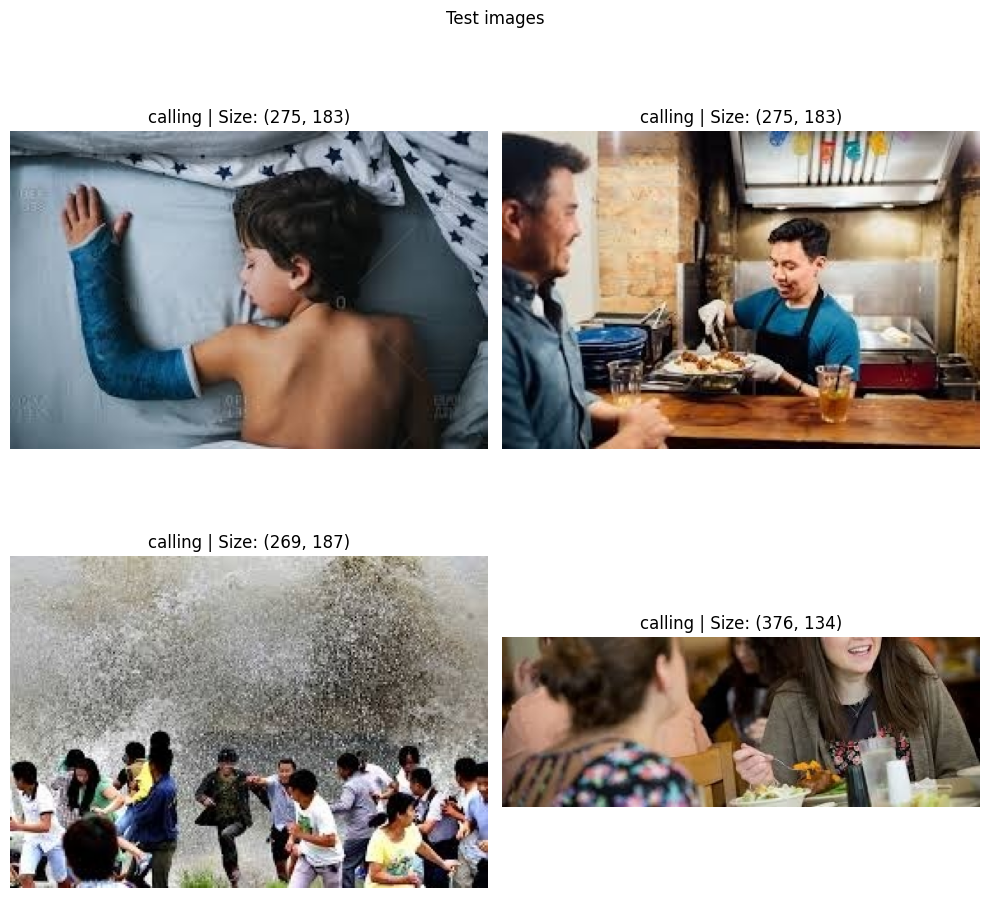

<Figure size 640x480 with 0 Axes>

In [13]:
show_N_images(ds['train'], labels, 4, sup_title="Train images", save_dir=FIGURES_DIR, save_name="train_images.png")
show_N_images(ds['test'], labels, 4, sup_title="Test images", save_dir=FIGURES_DIR, save_name="test_images.png")

Se observa que el conjunto de datos de test presenta un fuerte desbalanceo entre clases y, adicionalmente, se detectan inconsistencias en el etiquetado. Dado que este conjunto no cumple las condiciones necesarias para una evaluación fiable del modelo, se decide no utilizarlo en la fase de entrenamiento ni validación.

No obstante, este conjunto no se elimina, sino que se aparta deliberadamente. La motivación es doble. Por un lado, evitar que datos potencialmente mal etiquetados introduzcan ruido durante el aprendizaje y perjudiquen la convergencia del modelo. Por otro, preservar estas muestras para un uso futuro en un escenario de aprendizaje semisupervisado. El aprendizaje semisupervisado puede facilitarse teniendo varios modelos entrenados sobre el mismo dataset, y realizar una votación (basado en sus probabilidades) entre ellos para obtener predicciones más robustas.

Una vez se disponga de un modelo entrenado de forma robusta a partir del conjunto de entrenamiento balanceado, este podrá emplearse como modelo auxiliar para re-etiquetar o corregir parcialmente las etiquetas del conjunto de test, combinando predicciones automáticas con validación manual. Este enfoque permitiría recuperar valor de datos inicialmente descartados, aumentando el volumen efectivo de muestras sin comprometer la calidad del entrenamiento inicial.

En consecuencia, el proceso de balanceo se realiza exclusivamente sobre el conjunto de entrenamiento, garantizando que las decisiones de muestreo no introduzcan sesgos en la evaluación y manteniendo una separación estricta entre datos utilizados para aprender y datos reservados para futuras estrategias de mejora del dataset.

In [ ]:
ds = DatasetDict({
    'train': ds['train'],
    'noise': ds['test']
})

El siguiennte paso es analizar la distribución de ancho y alto de las imágenes.

In [15]:
ds['train'] = ds['train'].map(add_ds_image_size)
ds['noise'] = ds['noise'].map(add_ds_image_size)


Map:   0%|          | 0/12600 [00:00<?, ? examples/s]

Map:   0%|          | 0/5400 [00:00<?, ? examples/s]

Ahora se grafica en un scatterplot, con una nube de puntos los anchos y altos de cada imagen en función de su clase, ya que a lo mejor hay tendencias en función de estas

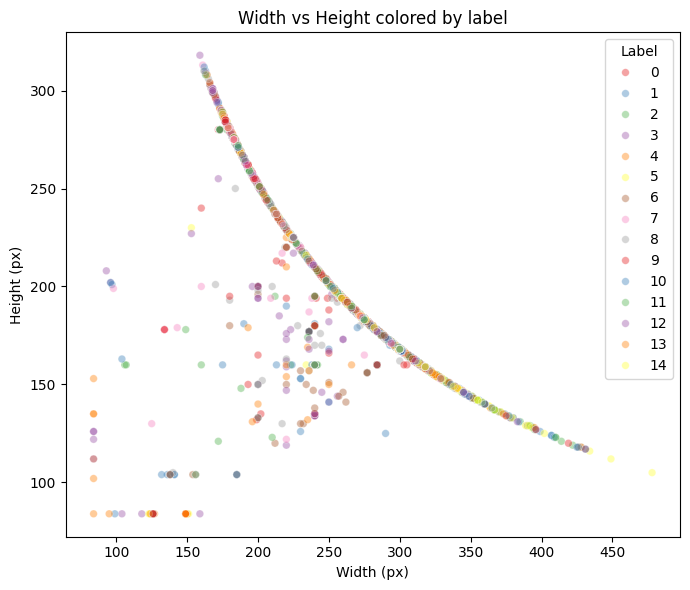

<Figure size 640x480 with 0 Axes>

In [16]:
df_vis = pd.DataFrame({
    "width": ds["train"]["width"],
    "height": ds["train"]["height"],
    "label": ds["train"]["labels"]
})

plt.figure(figsize=(7, 6), dpi = DPI_SHOW)
sns.scatterplot(
    data=df_vis,
    x="width",
    y="height",
    hue="label",
    alpha=0.4,
    s=30,
    palette="Set1"
)

plt.title("Width vs Height colored by label")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.legend(title="Label")
plt.tight_layout()
plt.show()
plt.savefig(f"{FIGURES_DIR}/width_vs_height.png", dpi = DPI)

En el grafico ilustrado se observa que "no hay dos imágenes con el  mismo tamaño", y no hay ninguna tendencia tampoco en función de la clase, pero si, se observa una clara agrupación de nube de puntos, "el arco".

Hay que establecer una manera de filtrar esas imágenes, ya que cuando se entrene un modelo interesa que todas las imágenes tengan resoluciones similares, asi al realizar escalados no se pierde tanta información.

Se procede a estudiar dos posibles formas de filtrar los datos:
1. Utilizar [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) ya que con clustering y una buena configuración se puede eliminar los outliers.
2. Eliminando los outliers a partir de los rangos intercuartilicos:
    *  Eliminar los outleirs a partir de $width$ y $height$.
    *  Eliminar los outliers a partir de $resolution$. Donde $resolution$ es el valor de la resolución ($width \times height$) de la imagen.


## Filtrado de datos

### 1. DBSCAN

DBSCAN realiza agrupaciones basado en densidad, es decir, agrupa los puntos que están cerca entre sí, para ello hay que determinar el radio de vecindad (`eps`) y el número mínimo de puntos para formar un cluster (`min_samples`). 

Uno de los pasos más importantes en DBSCAN es aplicar el escalado de los datos, en este caso los datos objetivo son la resolución de las imágenes.

In [17]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = np.column_stack([ds['train']['width'], ds['train']['height']])
X_scaled = StandardScaler().fit_transform(X)

Se ha probado para diferentes valores de `eps` y `min_samples`, finalmente se seleccionó la configuración de `eps=0.30` y `min_samples=20`.

In [18]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.30, min_samples=20)

clusters = dbscan.fit_predict(X_scaled)

DBSCAN marca con un -1 los valores que no pertenecen a ningún cluster.

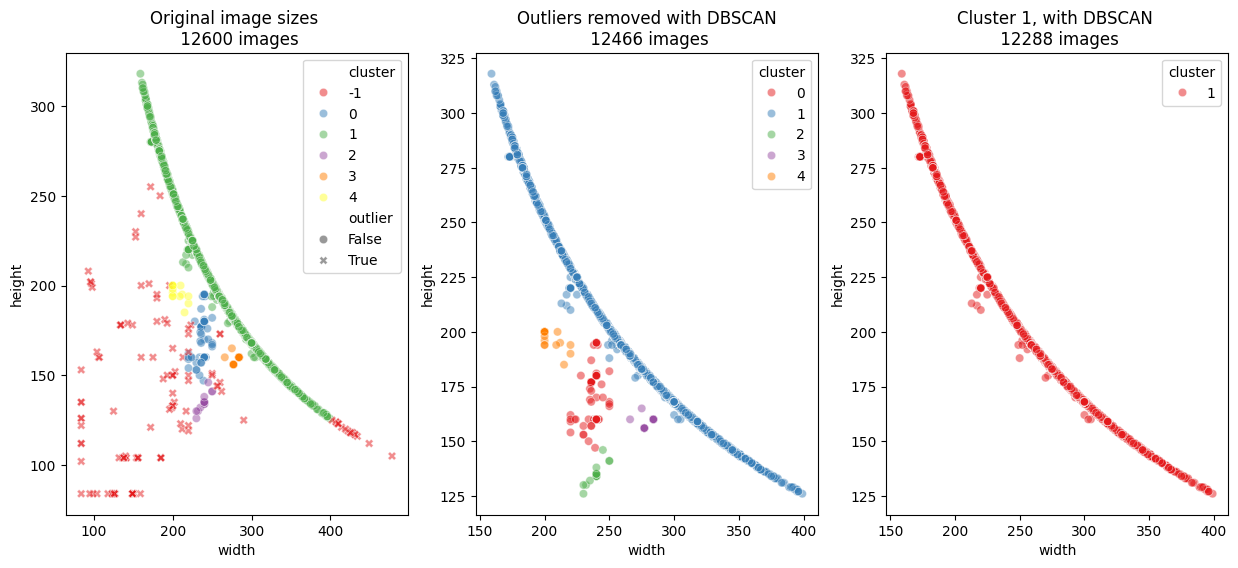

<Figure size 640x480 with 0 Axes>

In [19]:
df_dbscan = df_vis.copy()
df_dbscan["cluster"] = clusters
df_dbscan["outlier"] = df_dbscan["cluster"] == -1

fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi = DPI_SHOW)

sns.scatterplot(
    data=df_dbscan,
    x="width",
    y="height",
    hue="cluster",
    style="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Original image sizes \n {len(df_dbscan)} images")

sns.scatterplot(
    data=df_dbscan[df_dbscan["cluster"] != -1],
    x="width",
    y="height",
    hue="cluster",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)
axs[1].set_title(f"Outliers removed with DBSCAN\n {len(df_dbscan[df_dbscan['cluster'] != -1])} images")

sns.scatterplot(
    data=df_dbscan[(df_dbscan["cluster"] == 1)],
    x="width",
    y="height",
    hue="cluster",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[2]
)
axs[2].set_title(f"Cluster 1, with DBSCAN \n {len(df_dbscan[(df_dbscan['cluster'] == 1)])} images")
plt.show()
plt.savefig(f"{FIGURES_DIR}/dbscan.png", dpi = DPI)

De esta manera conseguimos reducir muchos outliers y seleccionando los clusters adecuados obtenemos una buena segmentación y filtrado de imagenes con una resolución aceptable.

Si se escogiera este método, filtrando solo con el cluster 1,3 y 7 se reduciría el tamaño del dataset, pero también se mejora su calidad.

In [ ]:
df_filtered = df_dbscan[(df_dbscan["cluster"] == 1)]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido a un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 312 imágenes, de un total de 12600.
Se ha reducido a un 97.52% del dataset.


### 2. Eliminación de outliers

In [ ]:
def get_quartiles_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3-q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[column]>upper) | (df[column]<lower)][column]
    min_value = df[column].min()
    max_value = df[column].max()
    return q1, q3, iqr, lower, upper, outliers, min_value, max_value

**Limitar el `width` y `height` a un threshold determinado.**

Para establecer unos límites de threshold se va a emplear el estudio de los rangos intercuartílicos, ya que con ello se puede detectar la presencia de outliers.

In [ ]:
q1_w, q3_w, iqr_w, lower_w, upper_w, outliers_w, _,_  = get_quartiles_outliers(df_vis, "width")
q1_h, q3_h, iqr_h, lower_h, upper_h, outliers_h, _,_  = get_quartiles_outliers(df_vis, "height")

df_threshold = df_vis.copy()

df_threshold["outlier"] = (
    (df_threshold["width"] < lower_w) |
    (df_threshold["width"] > upper_w) |
    (df_threshold["height"] < lower_h) |
    (df_threshold["height"] > upper_h)
)

In [ ]:
print(f"WIDTH -> Upper limit: {upper_w} | Lower limit: {lower_w}")
print(f"HEIGHT -> Upper limit: {upper_h} | Lower limit: {lower_h}")

WIDTH -> Upper limit: 309.0 | Lower limit: 221.0
HEIGHT -> Upper limit: 213.5 | Lower limit: 161.5


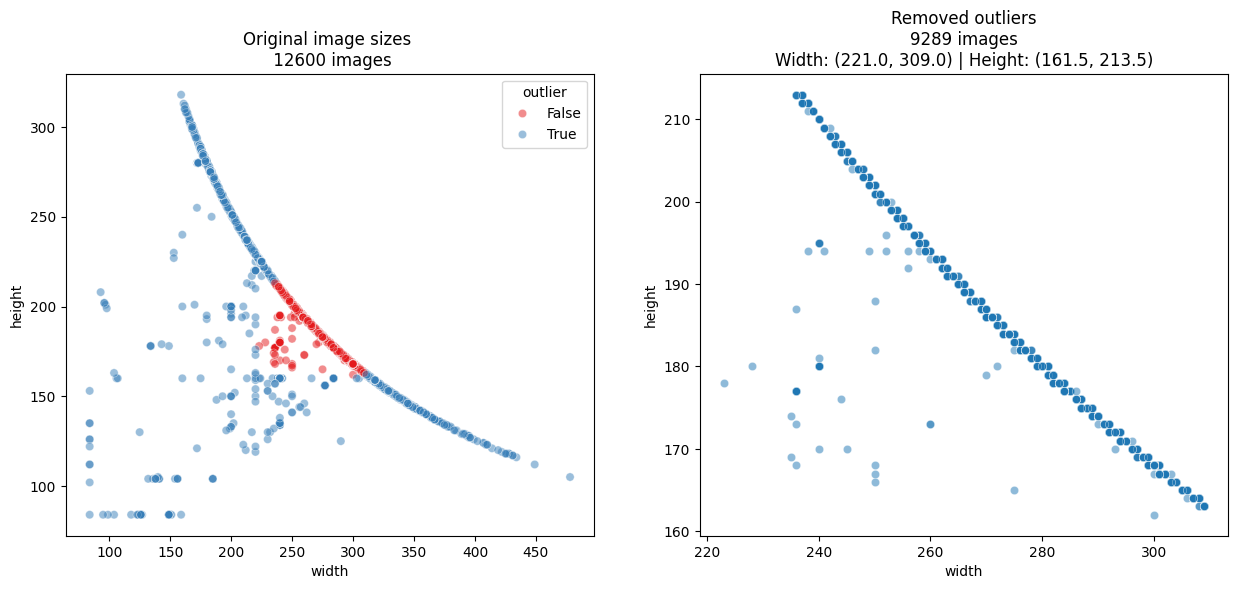

<Figure size 640x480 with 0 Axes>

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi=DPI_SHOW)

sns.scatterplot(
    data=df_threshold,
    x="width",
    y="height",
    hue="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Original image sizes \n {df_threshold.shape[0]} images")

sns.scatterplot(
    data=df_threshold[df_threshold["outlier"] == False],
    x="width",
    y="height",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)

title = (
    "Removed outliers\n"
    f"{df_threshold[df_threshold['outlier'] == False].shape[0]} images\n"
    f"Width: ({lower_w}, {upper_w}) | Height: ({lower_h}, {upper_h})"
)
axs[1].set_title(title)
plt.show()
plt.savefig(f"{FIGURES_DIR}/width_height_threshold.png", dpi=DPI)

Si se filtrasen los datos eliminando los outliers que se han detectado estudiando los rangos intercuartílicos se obtendría la siguiente reducción de datos:

In [ ]:
df_filtered = df_threshold[df_threshold['outlier']==False]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido a un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 3311 imágenes, de un total de 12600.
Se ha reducido a un 73.72% del dataset.


**Limitar el resolution a un threshold determinado**

In [ ]:
df_vis["resolution"] = df_vis["width"] * df_vis["height"]
q1_r, q3_r, iqr_r, lower_r, upper_r, outliers_r, _, _ = get_quartiles_outliers(df_vis, 'resolution')
df_threshold = df_vis.copy()

df_threshold["outlier"] = (
    (df_threshold["resolution"] < lower_r) |
    (df_threshold["resolution"] > upper_r)
)

In [ ]:
print(f"RESOLUTION -> Upper limit: {upper_r} | Lower limit: {lower_r}")

RESOLUTION -> Upper limit: 50572.5 | Lower limit: 50176.5


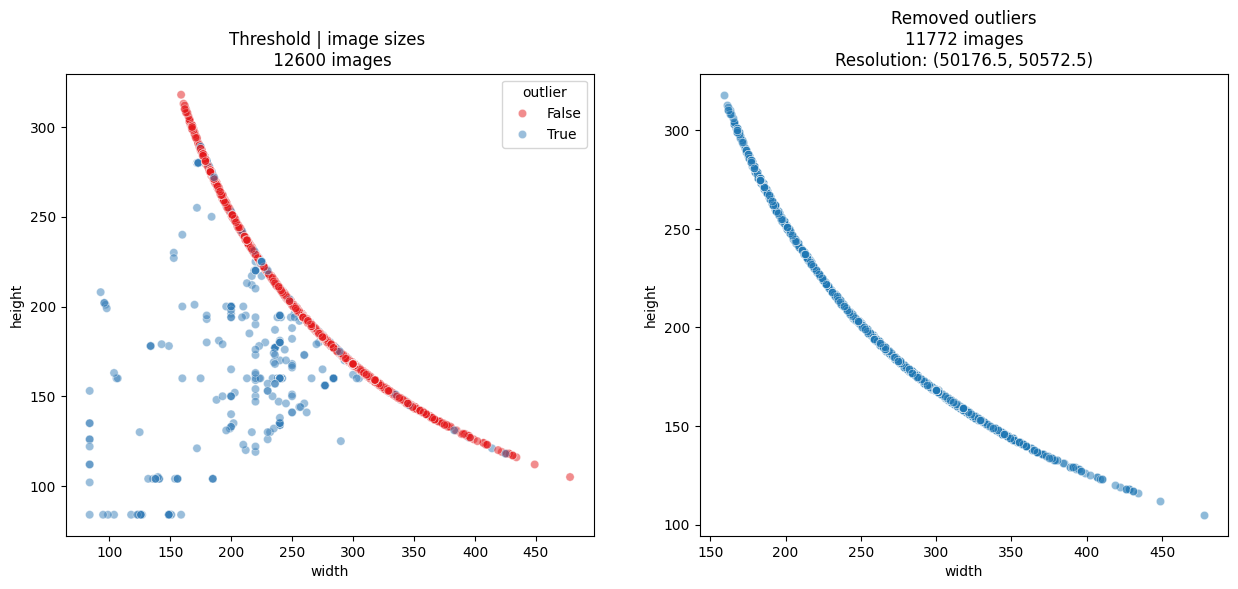

<Figure size 640x480 with 0 Axes>

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi = DPI_SHOW)

sns.scatterplot(
    data=df_threshold,
    x="width",
    y="height",
    hue="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Threshold | image sizes \n {len(df_threshold)} images")

sns.scatterplot(
    data=df_threshold[df_threshold["outlier"] == False],
    x="width",
    y="height",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)
title = (
    "Removed outliers\n"
    f"{df_threshold[df_threshold['outlier'] == False].shape[0]} images\n"
    f"Resolution: ({lower_r}, {upper_r})"
)
axs[1].set_title(title)

plt.show()
plt.savefig(f"{FIGURES_DIR}/resolution_threshold.png", dpi=DPI)

Se obtiene menos eliminaciones de datos que previamente filtrando con `height` y `width`.

A continuación se muestra la reducción obtenida con este proceso.

In [ ]:
df_filtered = df_threshold[df_threshold['outlier']==False]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 828 imágenes, de un total de 12600.
Se ha reducido un 93.43% del dataset.


**Combinando los dos thresholds**

El objetivo es eliminar solo los datos atípicos de manera intleigente, tratando de preservar la mayor cantidad de datos posibles.

Entonces se va a intentar quedar con los datos que no son outliers tanto al hacer lo del umbral de `height` y `width` y lo del umbral de `resolution`.

In [30]:
q1_w, q3_w, iqr_w, lower_w, upper_w, outliers_w, _,_  = get_quartiles_outliers(df_vis, "width")
q1_h, q3_h, iqr_h, lower_h, upper_h, outliers_h, _,_  = get_quartiles_outliers(df_vis, "height")

df_threshold = df_vis.copy()

df_threshold["outlier_hw"] = (
    (df_threshold["width"] < lower_w) |
    (df_threshold["width"] > upper_w) |
    (df_threshold["height"] < lower_h) |
    (df_threshold["height"] > upper_h)
)

df_vis["resolution"] = df_vis["width"] * df_vis["height"]
q1_r, q3_r, iqr_r, lower_r, upper_r, outliers_r, _, _ = get_quartiles_outliers(df_vis, 'resolution')

df_threshold["outlier_r"] = (
    (df_threshold["resolution"] < lower_r) |
    (df_threshold["resolution"] > upper_r)
)

In [31]:
def outlier_th(row: pd.Series):
    return (row["outlier_hw"]) & (row["outlier_r"])

df_threshold['outlier'] = df_threshold.apply(outlier_th, axis=1)


In [ ]:
print(f"WIDTH -> Upper limit: {upper_w} | Lower limit: {lower_w}")
print(f"HEIGHT -> Upper limit: {upper_h} | Lower limit: {lower_h}")
print(f"RESOLUTION -> Upper limit: {upper_r} | Lower limit: {lower_r}")

WIDTH -> Upper limit: 309.0 | Lower limit: 221.0
HEIGHT -> Upper limit: 213.5 | Lower limit: 161.5
RESOLUTION -> Upper limit: 50572.5 | Lower limit: 50176.5


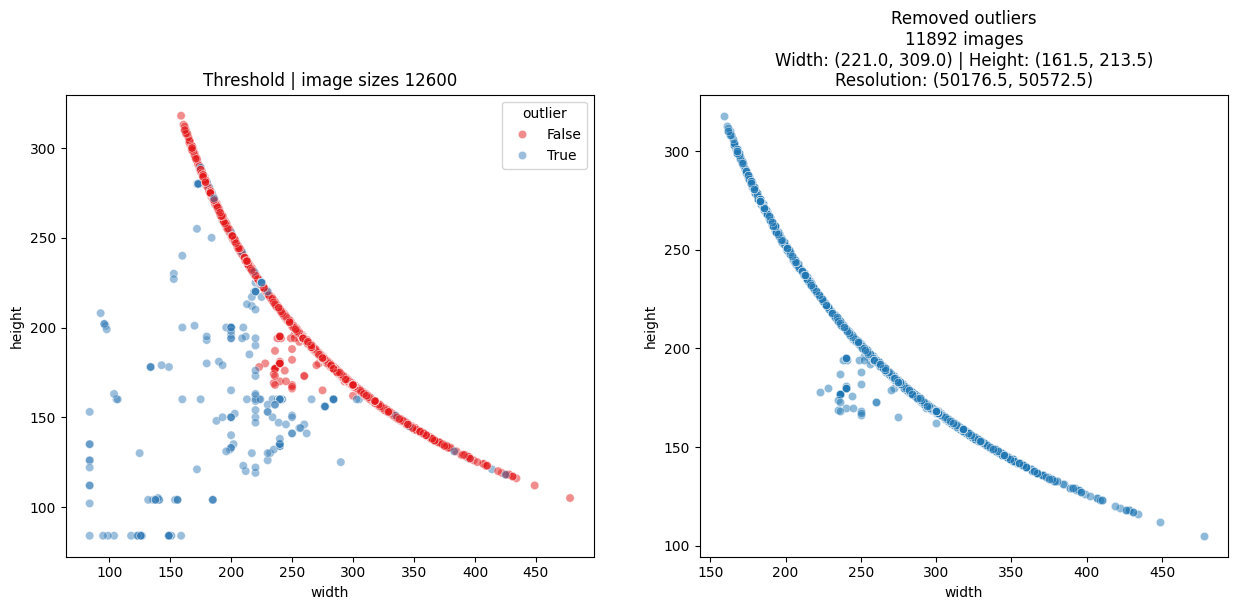

<Figure size 640x480 with 0 Axes>

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi = DPI_SHOW)

sns.scatterplot(
    data=df_threshold,
    x="width",
    y="height",
    hue="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Threshold | image sizes {len(df_threshold)}")

sns.scatterplot(
    data=df_threshold[df_threshold["outlier"] == False],
    x="width",
    y="height",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)

title = (
    "Removed outliers\n"
    f"{df_threshold[df_threshold['outlier'] == False].shape[0]} images\n"
    f"Width: ({lower_w}, {upper_w}) | Height: ({lower_h}, {upper_h})\n"
    f"Resolution: ({lower_r}, {upper_r})"
)
axs[1].set_title(title)
plt.show()
plt.savefig(f'{FIGURES_DIR}/width_height_resolution_threshold.png', dpi=DPI)

Ahora no se tiene tantos outliers, y se obtiene más datos, y de calidad.

A continuación se muestra la reducción final del dataset

In [ ]:
df_filtered = df_threshold[df_threshold['outlier']==False]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 708 imágenes, de un total de 12600.
Se ha reducido un 94.38% del dataset.


### 3. Selección final


Tras comparar las alternativas para homogeneizar el dataset (variabilidad de tamaños y resoluciones), se selecciona el método que mejor equilibra calidad de las muestras, interpretabilidad y preservación de datos. 


* DBSCAN: permite una segmentación razonable por densidad, pero el resultado depende de la búsqueda de hiperparámetros (eps, min_samples). Además, obliga a decidir a posteriori qué clusters se conservan, lo que reduce la reproducibilidad del pipeline y hace más difícil justificar el criterio de filtrado.

* Eliminación de outliers con umbrales IQR (get_quartiles_outliers):
    - Solo por width y height: el filtrado resulta demasiado agresivo porque marca como atípica una gran cantidad de imágenes válidas (se eliminan muchas muestras), lo que no es deseable para el entrenamiento.
    - Solo por resolution = width · height: el resultado es más favorable, ya que elimina principalmente resoluciones extremas y conserva la estructura principal del conjunto.
    - Criterio combinado (recomendado): eliminar una imagen únicamente si es outlier a la vez en dimensiones y en resolución. Este enfoque es el más equilibrado porque reduce falsos positivos (no elimina tantas muestras) y mantiene un criterio determinista y fácilmente interpretable.

Criterio final adoptado (interpretable y reproducible):

**Se elimina la muestra si: outlier_hw AND outlier_r**

* `outlier_hw`: fuera de los rangos IQR en width o height
* `outlier_r`: fuera del rango IQR en resolution

# Separación de los datos

Hay que dividir el dataset en train y test, preferiblemente la división debe ser aleatoria y balanceada.

Posteriormente, se hace el filtrado de los datos, no se hace previamente ya que si no las comparaciones que se hagan a posteriori no serían justas, ya que los datos no serían los mismos. Tal y como se propone así el punto de partida de train y test serían los mismos, aunque esto puede desbalancear un poco el dataset.

In [35]:
splits = ds["train"].train_test_split(
    test_size=0.2,
    seed=42,
    shuffle=True,
    stratify_by_column="labels"
)

ds["train"] = splits["train"]
ds["test"] = splits["test"]

In [36]:
def filtered_data(example):
    w = example["width"]
    h = example["height"]
    r = w * h

    outlier_wh = (w < lower_w or w > upper_w) or (h < lower_h or h > upper_h)
    outlier_r = r < lower_r or r > upper_r
    
    return not (outlier_wh and outlier_r)

ds_filtered = ds.filter(filtered_data)

Filter:   0%|          | 0/10080 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5400 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2520 [00:00<?, ? examples/s]

In [ ]:
print(f'Datos conjunto de entrenamiento:')
print(f'Original: {ds['train'].shape[0]} | Filtrado: {ds_filtered['train'].shape[0]}')

print(f'Datos conjunto de test:')
print(f'Original: {ds['test'].shape[0]} | Filtrado: {ds_filtered['test'].shape[0]}')

print(f'Datos conjunto de noise:')
print(f'Original: {ds['noise'].shape[0]} | Filtrado: {ds_filtered['noise'].shape[0]}')

Datos conjunto de entrenamiento:
Original: 10080 | Filtrado: 9508
Datos conjunto de test:
Original: 2520 | Filtrado: 2384
Datos conjunto de noise:
Original: 5400 | Filtrado: 5124


Observamos de nuevo el nuevo rebalanceo de los datos

In [38]:
counter_train_df = analysis_dataset(ds['train'], labels)
counter_test_df = analysis_dataset(ds['test'], labels)
counter_train_df_filtered = analysis_dataset(ds_filtered['train'], labels)
counter_test_df_filtered = analysis_dataset(ds_filtered['test'], labels)

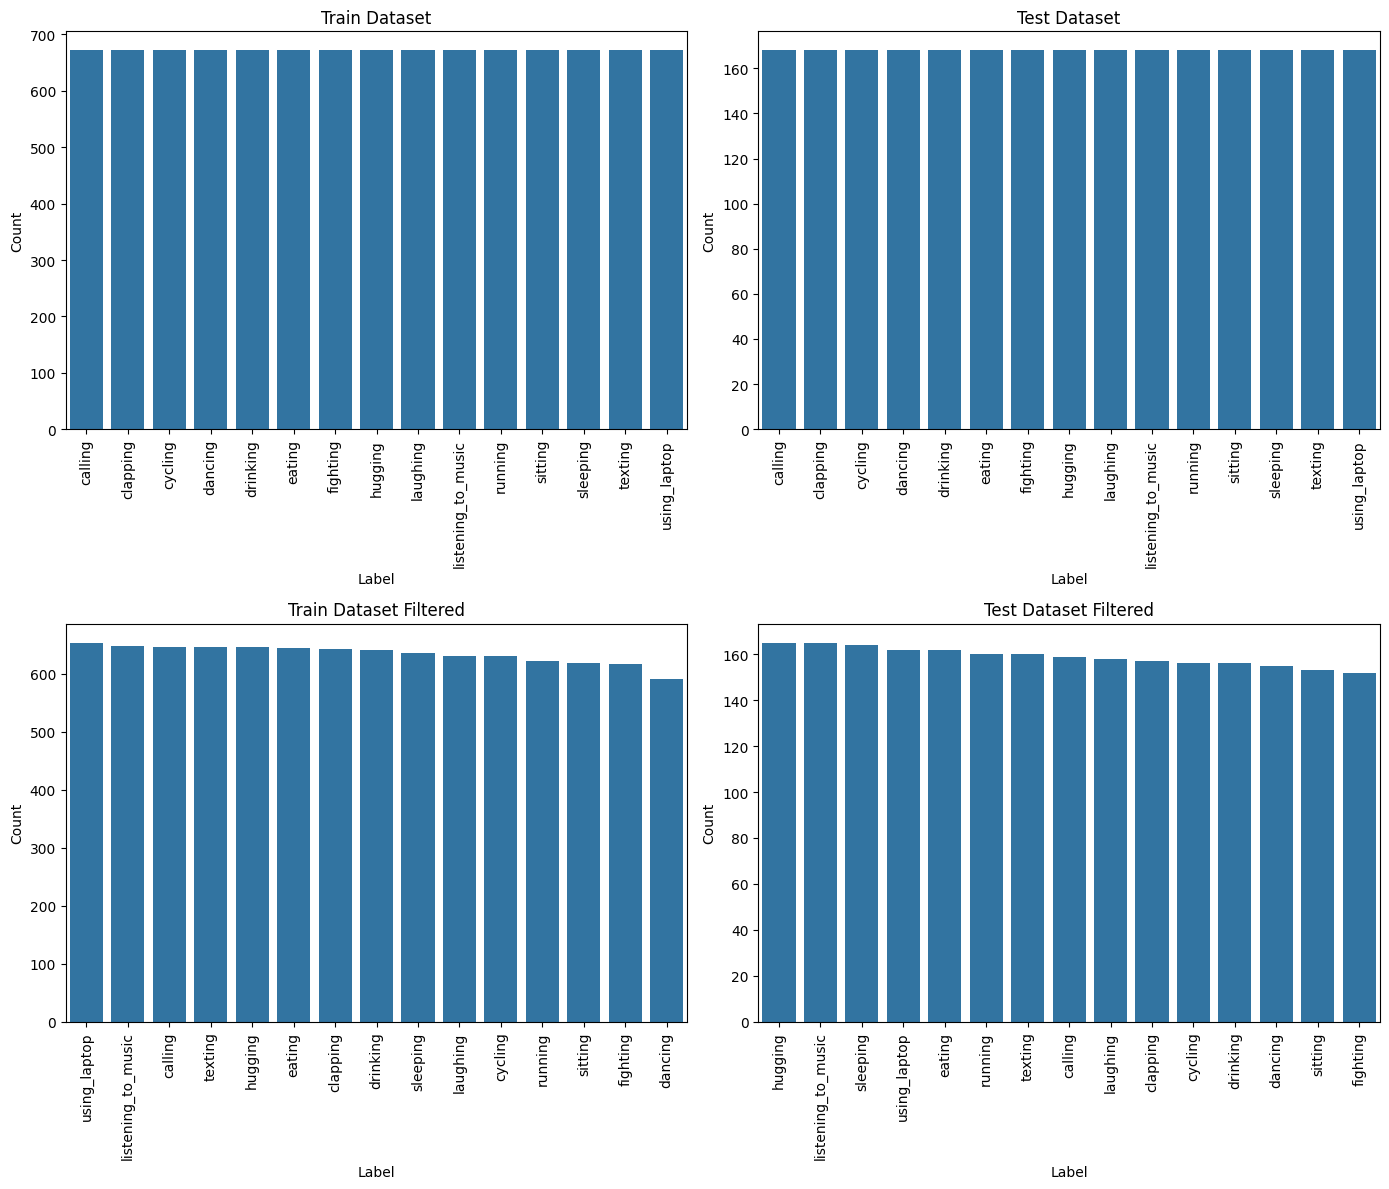

<Figure size 640x480 with 0 Axes>

In [39]:
fig, ax = plt.subplots(2, 2, figsize=(14, 12), dpi = DPI_SHOW)

sns.barplot(
    data=counter_train_df,
    x="Label",
    y="Count",
    ax=ax[0,0]
)
ax[0,0].set_title("Train Dataset")
ax[0,0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_test_df,
    x="Label",
    y="Count",
    ax=ax[0,1]
)
ax[0,1].set_title("Test Dataset")
ax[0,1].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_train_df_filtered,
    x="Label",
    y="Count",
    ax=ax[1,0]
)
ax[1,0].set_title("Train Dataset Filtered")
ax[1,0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_test_df_filtered,
    x="Label",
    y="Count",
    ax=ax[1,1]
)
ax[1,1].set_title("Test Dataset Filtered")
ax[1,1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()
plt.savefig(f'{FIGURES_DIR}/counter_train_test_balanced.png', dpi=DPI)


Ahora ya tenemos una visión completa de los datos y su distribución. 

Durante el proceso de entrenamiento de los modelos se probará los dos conjutnos de datos. EL primero, un dataset completamente balanceado, pero con imágenes de cualquier tamaño. El segundo, un dataset ligeramente desbalanceado, pero con imágenes de una resolución similar.

# Entrenamiento de los modelos

Se decide emplear el modelo [EfficientNet V2 B0](https://keras.io/api/applications/efficientnet_v2/), 

In [40]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import EfficientNetV2B0, vgg16
from tensorflow.keras.optimizers import Adam, SGD
from keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.models import Model

IMG_SIZE = 224          # EfficientNet V2 B0 usa 224 por defecto
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

NUM_CLASSES = len(labels)

Hay que convertir el dataset de Hugging Face a un dataset de imágenes de tensorflow.

In [64]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_raw = ds_filtered["train"].to_tf_dataset(
    columns=["image"],       # una sola columna => suele salir tensor, no dict
    label_cols=["labels"],
    shuffle=True,
    batch_size=1,            # necesario por tamaños variables
)
test_raw = ds_filtered["test"].to_tf_dataset(
    columns=["image"],       # una sola columna => suele salir tensor, no dict
    label_cols=["labels"],
    shuffle=True,
    batch_size=1,            # necesario por tamaños variables
)

def preprocess(image, label, training=False):
    # image: uint8 [H,W,3] (tras unbatch) o [1,H,W,3] (antes)
    image = tf.cast(image, tf.float32)
    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.08)
        image = tf.image.random_contrast(image, 0.9, 1.1)

    # IMPORTANTE: VGG16 preprocess
    image = tf.keras.applications.vgg16.preprocess_input(image)
    # image = tf.keras.applications.efficientnet.preprocess_input(image)
    label = tf.cast(label, tf.int32)
    return image, label

train = (
    train_raw
    .unbatch()
    .map(lambda x, y: preprocess(x, y, training=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test = (
    test_raw
    .unbatch()
    .map(lambda x, y: preprocess(x, y, training=False), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)



# sanity check
x, y = next(iter(train))
print(x.shape, y.shape)  # (BATCH_SIZE, 224, 224, 3) (BATCH_SIZE,)


/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


(32, 224, 224, 3) (32,)


In [65]:
# base_model = EfficientNetV2B0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model = vgg16.VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

In [66]:
for layer in base_model.layers:
    layer.trainable = False
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [68]:
x = base_model.output                      # (None, 7, 7, 1280)
x = GlobalAveragePooling2D()(x)                           # (None, 7*7*1280)
# x = Flatten()(x)                           # (None, 7*7*1280)

x = Dense(256, activation="relu", name="fc1", kernel_regularizer=keras.regularizers.l2(1e-3))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation="softmax", name="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # labels int (0..10)
    metrics=["accuracy"],
)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 15)             │         3,85

 Total params: 14,850,895 (56.65 MB)

 Trainable params: 135,695 (530.06 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [69]:
history = model.fit(train, validation_data=test, epochs=10)

Epoch 1/10
    298/Unknown 99s 319ms/step - accuracy: 0.1465 - loss: 3.7008

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


298/298 ━━━━━━━━━━━━━━━━━━━━ 123s 402ms/step - accuracy: 0.1467 - loss: 3.6996 - val_accuracy: 0.4304 - val_loss: 2.1804
Epoch 2/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 117s 392ms/step - accuracy: 0.3433 - loss: 2.5441 - val_accuracy: 0.5172 - val_loss: 1.8721
Epoch 3/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 116s 390ms/step - accuracy: 0.4338 - loss: 2.1806 - val_accuracy: 0.5570 - val_loss: 1.7315
Epoch 4/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 142s 476ms/step - accuracy: 0.4878 - loss: 1.9817 - val_accuracy: 0.5852 - val_loss: 1.6450
Epoch 5/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 117s 394ms/step - accuracy: 0.5151 - loss: 1.8721 - val_accuracy: 0.6044 - val_loss: 1.5883
Epoch 6/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 116s 390ms/step - accuracy: 0.5436 - loss: 1.7995 - val_accuracy: 0.6103 - val_loss: 1.5501
Epoch 7/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 142s 476ms/step - accuracy: 0.5523 - loss: 1.7286 - val_accuracy: 0.6179 - val_loss: 1.5120
Epoch 8/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 116s 389ms/step - accuracy: 0.5688 - loss: 1.67

In [70]:
for layer in base_model.layers:
    layer.trainable = True

In [71]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 15)             │         3,85

 Total params: 15,122,287 (57.69 MB)

 Trainable params: 14,850,383 (56.65 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 271,392 (1.04 MB)

In [72]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # labels int (0..10)
    metrics=["accuracy"],
)

In [ ]:
history_ft = model.fit(train, validation_data=test, epochs=10)

Epoch 1/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 281s 771ms/step - accuracy: 0.6075 - loss: 1.5676 - val_accuracy: 0.6657 - val_loss: 1.3804
Epoch 2/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 216s 726ms/step - accuracy: 0.6547 - loss: 1.3852 - val_accuracy: 0.6657 - val_loss: 1.3728
Epoch 3/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 215s 723ms/step - accuracy: 0.6868 - loss: 1.2820 - val_accuracy: 0.7013 - val_loss: 1.2601
Epoch 4/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 216s 725ms/step - accuracy: 0.7354 - loss: 1.1332 - val_accuracy: 0.7148 - val_loss: 1.2279
Epoch 5/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 263s 881ms/step - accuracy: 0.7573 - loss: 1.0762 - val_accuracy: 0.7307 - val_loss: 1.1753
Epoch 6/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 216s 726ms/step - accuracy: 0.7923 - loss: 0.9606 - val_accuracy: 0.7294 - val_loss: 1.1759
Epoch 7/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 217s 727ms/step - accuracy: 0.8094 - loss: 0.8930 - val_accuracy: 0.7374 - val_loss: 1.1455
Epoch 8/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 218s 731ms/step - accuracy: 0.8279 -

 91/298 ━━━━━━━━━━━━━━━━━━━━ 2:14 651ms/step - accuracy: 0.8766 - loss: 0.7041

: 

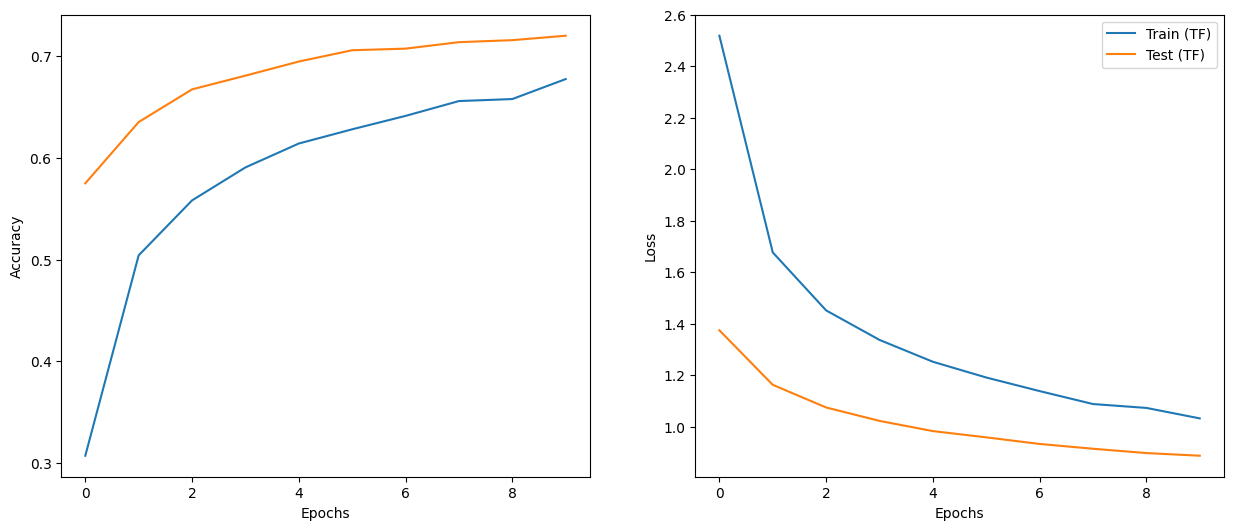

In [ ]:
# Step 6: Plot results
fig, axs = plt.subplots(1,2, figsize=(15,6))
epochs_tf = len(history.history['accuracy'])
# epochs_ft = len(history_ft.history['accuracy'])
axs[0].plot(range(0, epochs_tf), history.history['accuracy'], label='Train (TF)')
axs[0].plot(range(0, epochs_tf), history.history['val_accuracy'], label='Test (TF)')
# axs[0].plot(range(epochs_tf, epochs_tf+epochs_ft), history_ft.history['accuracy'], label='Train (FT)')
# axs[0].plot(range(epochs_tf, epochs_tf+epochs_ft), history_ft.history['val_accuracy'], label='Test (FT)')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy')
axs[1].plot(range(0, epochs_tf), history.history['loss'], label='Train (TF)')
axs[1].plot(range(0, epochs_tf), history.history['val_loss'], label='Test (TF)')
# axs[1].plot(range(epochs_tf, epochs_tf+epochs_ft), history_ft.history['loss'], label='Train (FT)')
# axs[1].plot(range(epochs_tf, epochs_tf+epochs_ft), history_ft.history['val_loss'], label='Test (FT)')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
plt.legend()
plt.show()

In [52]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_raw = ds_filtered["train"].to_tf_dataset(
    columns=["image"],       # una sola columna => suele salir tensor, no dict
    label_cols=["labels"],
    shuffle=True,
    batch_size=1,            # necesario por tamaños variables
)
test_raw = ds_filtered["test"].to_tf_dataset(
    columns=["image"],       # una sola columna => suele salir tensor, no dict
    label_cols=["labels"],
    shuffle=True,
    batch_size=1,            # necesario por tamaños variables
)

def preprocess(image, label):
    # image: uint8 [H,W,3] (tras unbatch) o [1,H,W,3] (antes)
    image = tf.cast(image, tf.float32)
    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    # image = tf.keras.applications.efficientnet.preprocess_input(image)
    image = tf.keras.applications.vgg16.preprocess_input(image)
    label = tf.cast(label, tf.int32)
    return image, label

train = (
    train_raw
    .unbatch()
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test = (
    test_raw
    .unbatch()
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)



# sanity check
x, y = next(iter(train))
print(x.shape, y.shape)  # (BATCH_SIZE, 224, 224, 3) (BATCH_SIZE,)


/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


(32, 224, 224, 3) (32,)


In [53]:
base_model = EfficientNetV2B0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [54]:
for layer in base_model.layers:
    layer.trainable = False
base_model.summary()

Model: "efficientnetv2-b0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 5,919,312 (22.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
x = base_model.output                      # (None, 7, 7, 1280)
x = GlobalAveragePooling2D()(x)                           # (None, 7*7*1280)

x = Dense(256, activation="relu", name="fc1", kernel_regularizer=regularizers.l2(1e-3))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation="softmax", name="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # labels int (0..10)
    metrics=["accuracy"],
)

In [56]:
history = model.fit(train, validation_data=test, epochs=10)

Epoch 1/10
    298/Unknown 101s 233ms/step - accuracy: 0.1082 - loss: 3.5221

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


298/298 ━━━━━━━━━━━━━━━━━━━━ 129s 328ms/step - accuracy: 0.1082 - loss: 3.5211 - val_accuracy: 0.2550 - val_loss: 2.2733
Epoch 2/10
 55/298 ━━━━━━━━━━━━━━━━━━━━ 45s 186ms/step - accuracy: 0.1834 - loss: 2.8061

KeyboardInterrupt: 

In [56]:
for layer in base_model.layers:
    layer.trainable = True

In [57]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # labels int (0..10)
    metrics=["accuracy"],
)

In [58]:
history_ft = model.fit(train, validation_data=test, epochs=10)

Epoch 1/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 225s 468ms/step - accuracy: 0.3812 - loss: 2.1712 - val_accuracy: 0.5373 - val_loss: 1.4738
Epoch 2/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 79s 264ms/step - accuracy: 0.4647 - loss: 1.7802 - val_accuracy: 0.5994 - val_loss: 1.2697
Epoch 3/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 80s 269ms/step - accuracy: 0.5100 - loss: 1.5886 - val_accuracy: 0.6338 - val_loss: 1.1576
Epoch 4/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 82s 276ms/step - accuracy: 0.5589 - loss: 1.4362 - val_accuracy: 0.6535 - val_loss: 1.0955
Epoch 5/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 142s 276ms/step - accuracy: 0.5927 - loss: 1.3059 - val_accuracy: 0.6762 - val_loss: 1.0381
Epoch 6/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 81s 271ms/step - accuracy: 0.6095 - loss: 1.2496 - val_accuracy: 0.6888 - val_loss: 0.9791
Epoch 7/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 82s 275ms/step - accuracy: 0.6289 - loss: 1.1709 - val_accuracy: 0.7018 - val_loss: 0.9534
Epoch 8/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 82s 274ms/step - accuracy: 0.6660 - loss:

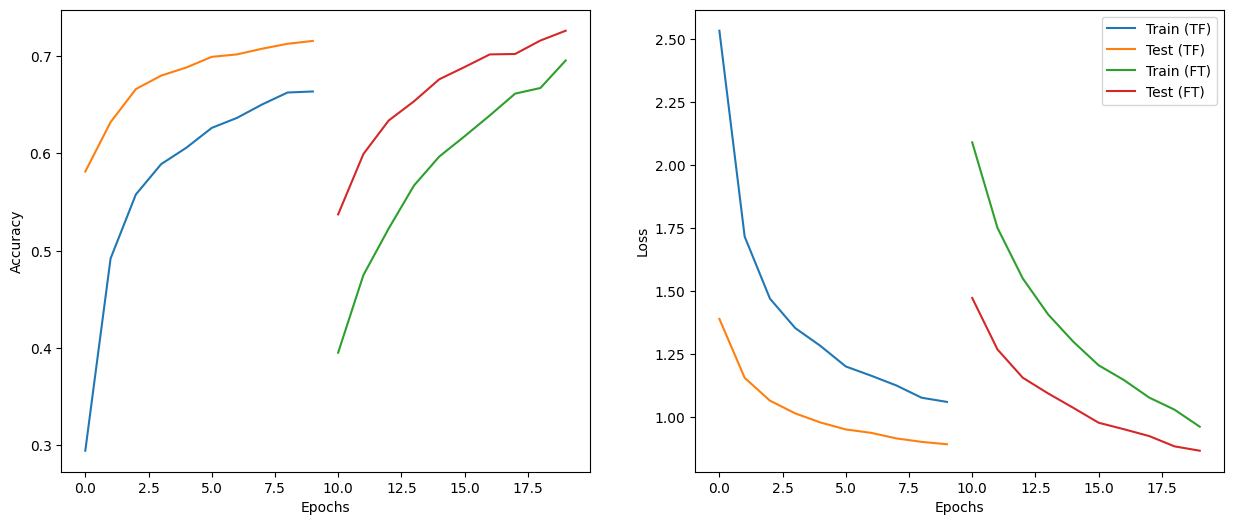

In [59]:
# Step 6: Plot results
fig, axs = plt.subplots(1,2, figsize=(15,6))
epochs_tf = len(history.history['accuracy'])
epochs_ft = len(history_ft.history['accuracy'])
axs[0].plot(range(0, epochs_tf), history.history['accuracy'], label='Train (TF)')
axs[0].plot(range(0, epochs_tf), history.history['val_accuracy'], label='Test (TF)')
axs[0].plot(range(epochs_tf, epochs_tf+epochs_ft), history_ft.history['accuracy'], label='Train (FT)')
axs[0].plot(range(epochs_tf, epochs_tf+epochs_ft), history_ft.history['val_accuracy'], label='Test (FT)')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy')
axs[1].plot(range(0, epochs_tf), history.history['loss'], label='Train (TF)')
axs[1].plot(range(0, epochs_tf), history.history['val_loss'], label='Test (TF)')
axs[1].plot(range(epochs_tf, epochs_tf+epochs_ft), history_ft.history['loss'], label='Train (FT)')
axs[1].plot(range(epochs_tf, epochs_tf+epochs_ft), history_ft.history['val_loss'], label='Test (FT)')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
plt.legend()
plt.show()